In [ ]:
import tensorflow as tf
import cv2
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from google.colab import drive
drive.mount('/content/drive')
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, Dropout

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
data_uas = ('/content/drive/MyDrive/Colab Notebooks/DatasetPandu/dataset')

In [ ]:
data = tf.keras.utils.image_dataset_from_directory(data_uas, image_size=(224, 224), batch_size=16)
print(data.class_names)
class_names = data.class_names

Found 300 files belonging to 3 classes.
['boots', 'heels', 'sneaker']


In [ ]:
data_iterator = data.as_numpy_iterator()
print("data_iterator", data_iterator)

data_iterator <tensorflow.python.data.ops.dataset_ops.NumpyIterator object at 0x7d13d569ce80>


In [ ]:
batch = data_iterator.next()
print("batch", batch)

batch (array([[[[225.      , 225.      , 223.      ],
         [224.      , 224.      , 222.      ],
         [224.      , 224.      , 222.      ],
         ...,
         [237.31697 , 237.31697 , 235.31697 ],
         [237.81094 , 237.81094 , 235.81094 ],
         [238.      , 238.      , 236.      ]],

        [[225.      , 225.      , 223.      ],
         [224.      , 224.      , 222.      ],
         [224.      , 224.      , 222.      ],
         ...,
         [238.0491  , 238.0491  , 236.0491  ],
         [237.3259  , 237.3259  , 235.3259  ],
         [237.0491  , 237.0491  , 235.0491  ]],

        [[225.      , 225.      , 223.      ],
         [224.      , 224.      , 222.      ],
         [224.      , 224.      , 222.      ],
         ...,
         [237.79468 , 237.79468 , 235.79468 ],
         [236.2768  , 236.2768  , 234.2768  ],
         [236.      , 236.      , 234.      ]],

        ...,

        [[240.24107 , 240.24107 , 238.24107 ],
         [239.      , 239.      , 237.

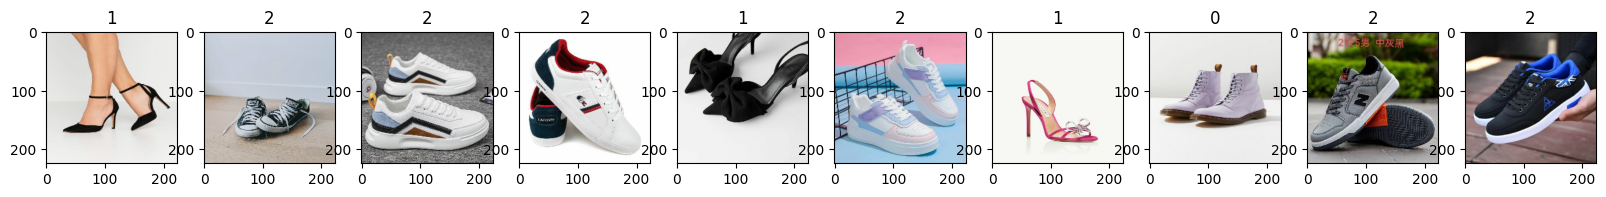

In [ ]:
fig, ax = plt.subplots(ncols=10, figsize=(20,20))
for idx, img in enumerate(batch[0][:10]):
    ax[idx].imshow(img.astype(int))
    ax[idx].title.set_text(batch[1][idx])

In [ ]:
data = data.map(lambda x, y: (x/255.0, y))
print("Data type after normalization: {}".format(data.element_spec))
print("Data shape after normalization: {}".format(data.element_spec))
print("Jumlah data", len(data))

Data type after normalization: (TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))
Data shape after normalization: (TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))
Jumlah data 19


In [ ]:
train_size = int(len(data)* 0.8)
val_size = int(len(data) * 0.1)
test_size = int(len(data)* 0.1)

print(train_size)
print(val_size)
print(test_size)

train = data.take(train_size)
val = data.skip(train_size).take(val_size)
test = data.skip(train_size+val_size).take(test_size)

15
1
1


In [ ]:
from tensorflow.keras.optimizers import Adam
model = Sequential()
model.add(Conv2D(96, (11, 11), strides=(4, 4), activation='relu', input_shape=(224, 224, 3)))
model.add(MaxPooling2D(pool_size=(3, 3), strides=(2, 2)))
model.add(Conv2D(256, (5, 5), padding='same', activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2), strides=(2, 2)))
model.add(Conv2D(384, (3, 3), padding='same', activation='relu'))
model.add(Conv2D(384, (3, 3), padding='same', activation='relu'))
model.add(Conv2D(256, (3, 3), padding='same', activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2), strides=(2, 2), padding='same'))
model.add(Flatten())
model.add(Dense(4096, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(4096, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(1000, activation='relu'))
model.add(Dense(len(class_names), activation='softmax'))

from tensorflow.keras.optimizers import Adamax
optimizer = Adamax(learning_rate=0.0001)
model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [ ]:
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_5 (Conv2D)           (None, 54, 54, 96)        34944     
                                                                 
 max_pooling2d_3 (MaxPoolin  (None, 26, 26, 96)        0         
 g2D)                                                            
                                                                 
 conv2d_6 (Conv2D)           (None, 26, 26, 256)       614656    
                                                                 
 max_pooling2d_4 (MaxPoolin  (None, 13, 13, 256)       0         
 g2D)                                                            
                                                                 
 conv2d_7 (Conv2D)           (None, 13, 13, 384)       885120    
                                                                 
 conv2d_8 (Conv2D)           (None, 13, 13, 384)      

In [ ]:
history = model.fit(train, epochs=100, validation_data=val)

Epoch 1/100
15/15 [==============================] - 30s 2s/step - loss: 1.0935 - accuracy: 0.3708 - val_loss: 1.0582 - val_accuracy: 0.3750
Epoch 2/100
15/15 [==============================] - 2s 139ms/step - loss: 1.0653 - accuracy: 0.3708 - val_loss: 1.0448 - val_accuracy: 0.5000
Epoch 3/100
15/15 [==============================] - 2s 138ms/step - loss: 0.9330 - accuracy: 0.6333 - val_loss: 0.9747 - val_accuracy: 0.3750
Epoch 4/100
15/15 [==============================] - 3s 141ms/step - loss: 0.7649 - accuracy: 0.6500 - val_loss: 0.3718 - val_accuracy: 0.9375
Epoch 5/100
15/15 [==============================] - 5s 283ms/step - loss: 0.7498 - accuracy: 0.7083 - val_loss: 0.7689 - val_accuracy: 0.6250
Epoch 6/100
15/15 [==============================] - 2s 130ms/step - loss: 0.7512 - accuracy: 0.6750 - val_loss: 0.6134 - val_accuracy: 0.7500
Epoch 7/100
15/15 [==============================] - 3s 151ms/step - loss: 0.5655 - accuracy: 0.8042 - val_loss: 0.1671 - val_accuracy: 0.9375
E

<function matplotlib.pyplot.show(close=None, block=None)>

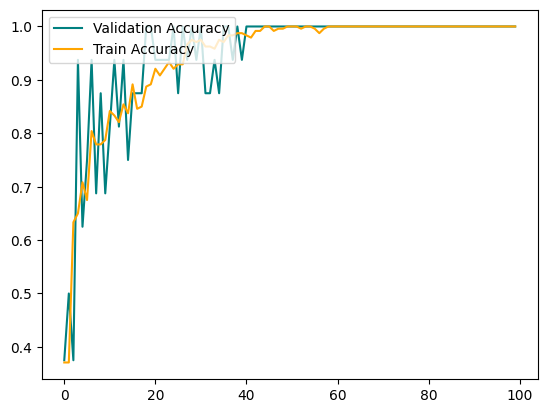

In [ ]:
fig = plt.figure()
plt.plot(history.history['val_accuracy'],color='teal',label = 'Validation Accuracy')
plt.plot(history.history['accuracy'],color='orange',label='Train Accuracy')
plt.legend(loc="upper left")
plt.show

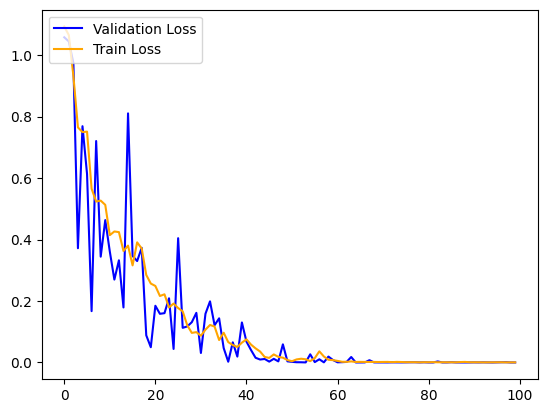

In [ ]:
fig = plt.figure()
plt.plot(history.history['val_loss'],color='blue', label='Validation Loss')
plt.plot(history.history['loss'],color='orange', label='Train Loss')
plt.legend(loc="upper left")
plt.show()

In [ ]:
model.evaluate(test)

1/1 [==============================] - 2s 2s/step - loss: 1.7793e-04 - accuracy: 1.0000


[0.00017793269944377244, 1.0]

In [ ]:
model.save('/content/drive/MyDrive/Colab Notebooks/DatasetPandu/hasil/AlexNetUAS.h5')

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(
